#Fraud Detection with Graph Neural Network (GNN)

There Are 2 ways of Import Data. In 2026, I use the 2nd way (Using Kagglehub). Make sure you are agreed with competition terms with kaggle since this dataset come from expired kaggle competition.

##Import Data (Data Extraction)

In [ ]:
#! pip install -q kaggle

In [ ]:
#Create .kaggle directory on root directory
! mkdir ~/.kaggle
from google.colab import files
files.upload()
#upload your kaggle.json as your Kaggle API
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json # Change Kaggle file permission

mkdir: cannot create directory ‘/root/.kaggle’: File exists


Saving KaggleAPI.txt to KaggleAPI (1).txt
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# Download dataset
! kaggle competitions download -c ieee-fraud-detection

 96% 113M/118M [00:01<00:00, 96.3MB/s] 
100% 118M/118M [00:01<00:00, 93.8MB/s]


In [ ]:
# Unzip data
!unzip ieee-fraud-detection.zip

Archive:  ieee-fraud-detection.zip
  inflating: sample_submission.csv   
  inflating: test_identity.csv       
  inflating: test_transaction.csv    
  inflating: train_identity.csv      
  inflating: train_transaction.csv   


## Import Data (Kagglehub)

Install Kagglehub, just install once if you don't have the library.

In [ ]:
! pip install kagglehub # Once in time

Login into kagglehub with your API key.

In [2]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


Just Download the dataset

In [3]:
# Download latest version
path = kagglehub.competition_download('ieee-fraud-detection')

print("Path to competition files:", path)

100%|██████████| 118M/118M [00:00<00:00, 128MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/ieee-fraud-detection


Look for the dataset path and its content.

In [ ]:
ls /root/.cache/kagglehub/competitions/ieee-fraud-detection

sample_submission.csv  test_transaction.csv  train_transaction.csv
test_identity.csv      train_identity.csv


## Data Merge and Overview

Import downloaded dataset into dataframe with pandas.

In [4]:
import pandas as pd
import numpy as np

root_path = '/root/.cache/kagglehub/competitions/ieee-fraud-detection'
data_id_train = pd.read_csv(root_path +'/train_identity.csv')
data_trans_train = pd.read_csv(root_path +'/train_transaction.csv')
data_id_test = pd.read_csv(root_path + '/test_identity.csv')
data_trans_test = pd.read_csv(root_path + '/test_transaction.csv')

Show all the dataframe

In [ ]:
data_trans_train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
data_id_train.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [ ]:
data_id_test.head()

,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,...,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3,3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
4,3663602,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW


In [ ]:
data_trans_test.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Merge dataset
training_df = pd.merge(data_trans_train, data_id_train, on='TransactionID', how='left')
test_df = pd.merge(data_trans_test, data_id_test, on='TransactionID', how='left')

In [ ]:
training_df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
test_df.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h3>Identity Table</h3>
<p>Variabel dalam tabel ini adalah informasi identitas - informasi koneksi jaringan (IP, ISP, Proxy, dll) dan tanda tangan digital (UA/browser/os/versi, dll) yang terkait dengan transaksi. Informasi ini dikumpulkan oleh sistem perlindungan penipuan dan mitra keamanan digital Vesta. (Nama bidang disamarkan dan kamus berpasangan tidak akan disediakan untuk perlindungan privasi dan perjanjian kontrak)

Fitur Kategorikal:

DeviceType<br>
DeviceInfo<br>
id_12 - id_38

In [6]:
training_df.isna().sum()

,0
TransactionID,0
isFraud,0
TransactionDT,0
TransactionAmt,0
ProductCD,0
...,...
id_36,711
id_37,711
id_38,711
DeviceType,711


In [ ]:
training_df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,3.000000e+02,300.000000,300.000000,300.000000,300.000000,295.000000,300.000000,300.000000,260.000000,260.0,...,68.000000,14.000000,68.000000,68.000000,2.0,2.0,2.0,2.0,2.000000,39.000000
mean,2.987150e+06,0.016667,88869.640000,179.132407,10007.626667,368.281356,153.916667,202.056667,290.942308,87.0,...,186.573529,14.214286,341.073529,417.705882,252.0,14.0,11.0,321.0,143.000000,28.717949
std,8.674676e+01,0.128233,1332.203783,402.019512,5118.074490,161.651044,12.149696,38.480766,95.639125,0.0,...,31.810688,1.625687,139.270628,139.827085,0.0,0.0,0.0,0.0,57.982756,3.986482
min,2.987000e+06,0.000000,86400.000000,3.081000,1085.000000,100.000000,117.000000,100.000000,122.000000,87.0,...,121.000000,12.000000,100.000000,142.000000,252.0,14.0,11.0,321.0,102.000000,24.000000
25%,2.987075e+06,0.000000,87778.000000,36.980000,5433.000000,220.000000,150.000000,169.750000,204.000000,87.0,...,166.000000,13.000000,266.000000,320.000000,252.0,14.0,11.0,321.0,122.500000,24.000000
50%,2.987150e+06,0.000000,88864.500000,59.000000,10046.000000,375.000000,150.000000,226.000000,299.000000,87.0,...,166.000000,15.000000,290.000000,503.500000,252.0,14.0,11.0,321.0,143.000000,32.000000
75%,2.987224e+06,0.000000,89966.750000,129.711750,14349.000000,514.000000,150.000000,226.000000,330.000000,87.0,...,225.000000,15.000000,419.500000,533.000000,252.0,14.0,11.0,321.0,163.500000,32.000000
max,2.987299e+06,1.000000,91172.000000,3000.000000,18370.000000,599.000000,185.000000,226.000000,512.000000,87.0,...,225.000000,18.000000,650.000000,600.000000,252.0,14.0,11.0,321.0,184.000000,32.000000


In [ ]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1017.3+ KB


In [ ]:
test_df.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
test_df.describe()

,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,...,id-17,id-18,id-19,id-20,id-21,id-22,id-24,id-25,id-26,id-32
count,1.000000e+02,1.000000e+02,100.000000,100.000000,99.000000,100.000000,100.000000,96.000000,96.0,52.000000,...,9.000000,7.0,9.000000,9.000000,0.0,0.0,0.0,0.0,0.0,5.000000
mean,3.663598e+06,1.840432e+07,133.535180,11065.530000,318.939394,151.400000,190.550000,320.135417,87.0,105.096154,...,192.222222,15.0,404.666667,357.333333,NaN,NaN,NaN,NaN,NaN,30.400000
std,2.901149e+01,6.468490e+02,124.301914,4864.935681,159.897787,6.893123,48.481044,122.509945,0.0,411.790079,...,31.095730,0.0,96.935546,180.136060,NaN,NaN,NaN,NaN,NaN,3.577709
min,3.663549e+06,1.840322e+07,6.271000,1214.000000,100.000000,150.000000,102.000000,110.000000,87.0,0.000000,...,166.000000,15.0,271.000000,177.000000,NaN,NaN,NaN,NaN,NaN,24.000000
25%,3.663574e+06,1.840384e+07,51.693500,7553.000000,170.500000,150.000000,138.000000,216.250000,87.0,3.000000,...,166.000000,15.0,352.000000,177.000000,NaN,NaN,NaN,NaN,NaN,32.000000
50%,3.663598e+06,1.840426e+07,97.000000,11523.000000,321.000000,150.000000,226.000000,315.000000,87.0,7.000000,...,166.000000,15.0,352.000000,368.000000,NaN,NaN,NaN,NaN,NaN,32.000000
75%,3.663623e+06,1.840483e+07,162.712500,15715.000000,478.500000,150.000000,226.000000,441.000000,87.0,19.000000,...,225.000000,15.0,427.000000,507.000000,NaN,NaN,NaN,NaN,NaN,32.000000
max,3.663648e+06,1.840546e+07,761.950000,18366.000000,583.000000,185.000000,226.000000,512.000000,87.0,2635.000000,...,225.000000,15.0,567.000000,563.000000,NaN,NaN,NaN,NaN,NaN,32.000000


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 433 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(3), object(31)
memory usage: 338.4+ KB


<h3>Data Description</h3>

<ul><th>Transaction Table
<li>TransactionDT: timedelta dari tanggal waktu referensi yang diberikan (bukan cap waktu yang sebenarnya)
<li>TransactionAMT: besar nilai transaksi dalam kurs USD
<li>ProductCD: kode produk
<li>card1 - card6: informasi kartu pembayaran, seperti jenis kartu, kategori kartu, bank penerbit, negara, dll.
<li>addr: alamat
<li>dist: jarak
<li>P_ and (R__) emaildomain: domain email pembeli dan penerima
<li>C1-C14: penghitungan, seperti berapa banyak alamat yang ditemukan terkait dengan kartu pembayaran, dll. Makna yang sebenarnya disembunyikan.
<li>D1-D15: timedelta, seperti selisih waktu dengan pembelian terakhir, dll.
<li>M1-M9: match, kecocokan informasi pribadi pada kartu dan alamat, dll.
<li>Vxxx: Vesta merekayasa fitur-fitur yang kaya, termasuk pemeringkatan, penghitungan, dan relasi entitas lainnya.
</ul>
<ul><th>Categorical Features:

<li>ProductCD
<li>card1 - card6
<li>addr1, addr2
<li>P_emaildomain
<li>R_emaildomain
<li>M1 - M9
</ul>

## EDA

In [6]:
import matplotlib.pyplot as plt
import seaborn as sn

This Majority non fraud transaction makes me realize and understanding the question asked for this problem. It's not to classify the fraud transaction, but the fraud identity (credit card) that used for fraud.

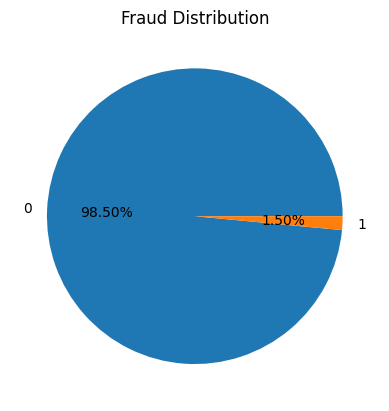

In [9]:
plt.pie(training_df.isFraud.value_counts(), labels = training_df.isFraud.value_counts().index, autopct = '%1.2f%%')
plt.title('Fraud Distribution')
plt.show()

This dataset has many NaN values inside. At first, I want to remove all the columns that has more NaN values. But, this might the wrong approach if there is column that can be powerful even it contains NaN values majority.

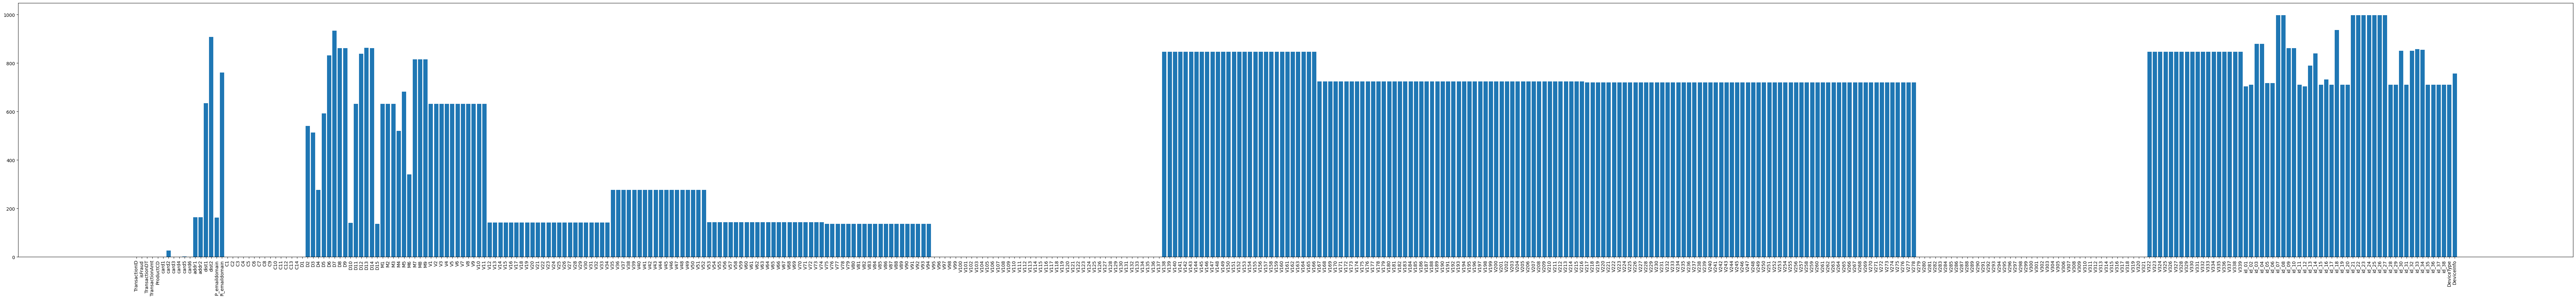

In [14]:
bar_x = training_df.columns
bar_y = training_df.isna().sum()
plt.figure(figsize=(100,10))
plt.xticks(rotation=90)
plt.bar(bar_x, bar_y)
plt.show()

The next is to find the most needed features for training and fraud detection. I will try to analyze this with correlation analysis.

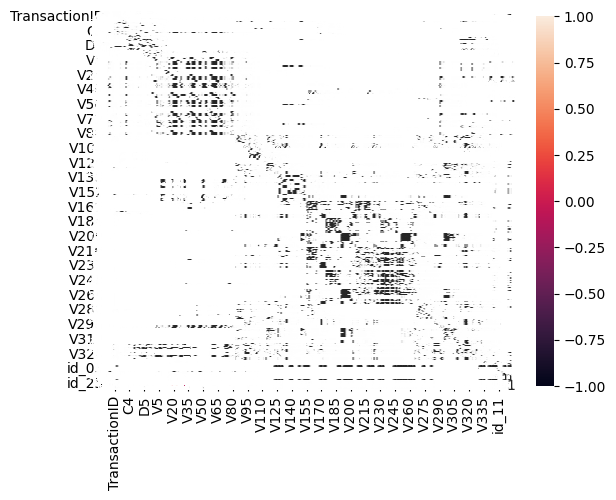

In [16]:
# Correlation Analysis (numeric only)
numeric_train_df = training_df.select_dtypes(include=['int16', 'int32', 'int64', 'float16', 'float32', 'float64'])
corr_matrix = numeric_train_df.corr()
sn.heatmap(corr_matrix, annot=True)
plt.show()

In [7]:
# Tampilkan hanya fraud transaction
fraud_df = training_df[training_df.isFraud == 1]
fraud_df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
203,2987203,1,89760,445.000,W,18268,583.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
240,2987240,1,90193,37.098,C,13413,103.0,185.0,visa,137.0,...,chrome 54.0 for android,NaN,NaN,NaN,F,F,T,T,mobile,Redmi Note 4 Build/MMB29M
243,2987243,1,90246,37.098,C,13413,103.0,185.0,visa,137.0,...,chrome 54.0 for android,NaN,NaN,NaN,F,F,T,T,mobile,Redmi Note 4 Build/MMB29M
245,2987245,1,90295,37.098,C,13413,103.0,185.0,visa,137.0,...,chrome 54.0 for android,NaN,NaN,NaN,F,F,T,T,mobile,Redmi Note 4 Build/MMB29M
288,2987288,1,90986,155.521,C,16578,545.0,185.0,visa,226.0,...,chrome 62.0 for ios,NaN,NaN,NaN,F,F,F,F,mobile,NaN


EDA and Feature Selection will be continued on other notebook

## Data Preprocessing

A. Missing Values Handling

## PCA

Extraction Feature with PCA. PCA is usual method used to extract tabular feature.

## Data Loader

In [ ]:
id_columns = ['card1','card2','card3','card4','card5','card6','ProductCD','addr1','addr2','P_emaildomain','R_emaildomain']
categories = ['M1','M2','M3','M4','M5','M6','M7','M8','M9']

In [ ]:
test_ids = data_trans_test.TransactionID.values

In [ ]:
with open('data/testID.csv', 'w') as f:
    f.writelines(map(lambda x: str(x) + "\n", test_ids))

In [ ]:
non_feature_cols = ['isFraud', 'TransactionDT'] + id_columns
print(non_feature_cols)

['isFraud', 'TransactionDT', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'ProductCD', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']


In [ ]:
feature_cols = [col for col in data_trans_train.columns if col not in non_feature_cols]
print(feature_cols)

['TransactionID', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102',

In [ ]:
features = pd.get_dummies(data_trans_train[feature_cols], columns=categories).fillna(0)
features['TransactionAmt'] = features['TransactionAmt'].apply(np.log10)
print(list(features.columns))

['TransactionID', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109

In [ ]:
features.to_csv('data/features.csv', index=False, header=False)
data_trans_train[['TransactionID', 'isFraud']].to_csv('data/tags.csv', index=False)

In [ ]:
all_id_cols = ['TransactionID'] + id_columns
full_identity_df = data_trans_train[all_id_cols].merge(data_id_train, on='TransactionID', how='left')
full_identity_df.head()

,TransactionID,card1,card2,card3,card4,card5,card6,ProductCD,addr1,addr2,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,13926,NaN,150.0,discover,142.0,credit,W,315.0,87.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,2755,404.0,150.0,mastercard,102.0,credit,W,325.0,87.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,4663,490.0,150.0,visa,166.0,debit,W,330.0,87.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,18132,567.0,150.0,mastercard,117.0,debit,W,476.0,87.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,4497,514.0,150.0,mastercard,102.0,credit,H,420.0,87.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
edge_types = id_columns + list(data_id_train.columns)
print(list(edge_types))

['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'ProductCD', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [ ]:
edges = {}
for etype in edge_types:
    edgelist = full_identity_df[['TransactionID', etype]].dropna()
    edgelist.to_csv('data/relation_{}_edgelist.csv'.format(etype), index=False, header=True)
    edges[etype] = edgelist

print(edges)

{'card1':         TransactionID  card1
0             2987000  13926
1             2987001   2755
2             2987002   4663
3             2987003  18132
4             2987004   4497
...               ...    ...
590535        3577535   6550
590536        3577536  10444
590537        3577537  12037
590538        3577538   7826
590539        3577539  15066

[590540 rows x 2 columns], 'card2':         TransactionID  card2
1             2987001  404.0
2             2987002  490.0
3             2987003  567.0
4             2987004  514.0
5             2987005  555.0
...               ...    ...
590534        3577534  408.0
590536        3577536  225.0
590537        3577537  595.0
590538        3577538  481.0
590539        3577539  170.0

[581607 rows x 2 columns], 'card3':         TransactionID  card3
0             2987000  150.0
1             2987001  150.0
2             2987002  150.0
3             2987003  150.0
4             2987004  150.0
...               ...    ...
590535        357

## Data Modeling

In [ ]:
import os
import json
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms

try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

In [ ]:
edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

# Buat Data PyTorch Geometric
data = Data(x=node_features, edge_index=edge_index, y=labels)

In [ ]:
class GNNModel(nn.Module):

    def __init__(self, c_in, c_hidden, c_out, num_layers=2, dp_rate=0.1, **kwargs):
        """
        Inputs:
            c_in - Dimension of input features
            c_hidden - Dimension of hidden features
            c_out - Dimension of output features (usually number of classes)
            num_layers - Number of layers in the GNN model
            dp_rate - Dropout rate to be used
            kwargs - Additional arguments for the GNNModel object
        """
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(geom_nn.GCNConv(c_in, c_hidden))
        for _ in range(num_layers - 1):
            self.layers.append(geom_nn.GCNConv(c_hidden, c_hidden))
        self.linear = nn.Linear(c_hidden, c_out)
        self.dp_rate = dp_rate

    def forward(self, x, edge_index):
        """
        Inputs:
            x - Input features per node
            edge_index - List of vertex index pairs representing the edges in the graph (PyTorch geometric notation)
        """
        for layer in self.layers:
            x = layer(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dp_rate, training=self.training)
        x = self.linear(x)
        return x
